In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Analyse exploratoire des données

### Distribution

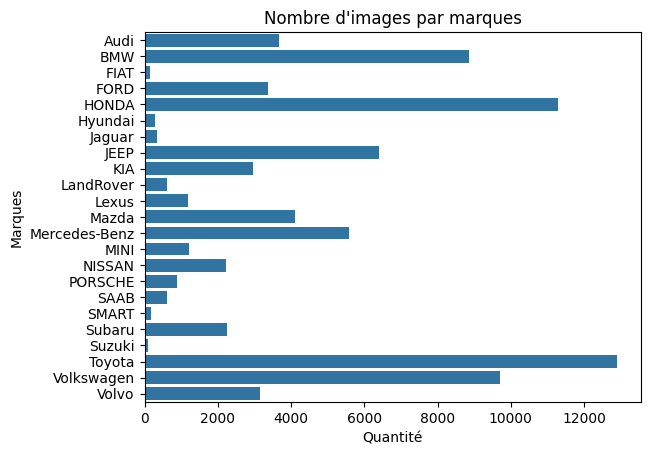

In [6]:
path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'

#On récupère toutes les marques du dataset
marques = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]


#On compte le nombres d'images par marques
nb_pictures = []
for brand in os.listdir(path):
    brand_path=os.path.join(path, brand)
    if os.path.isdir(brand_path):
        num_images = len([f for f in os.listdir(brand_path) if os.path.isfile(os.path.join(brand_path, f))])
        nb_pictures.append(num_images)

#On affiche les résultats
plt.figure()
sns.barplot(x=nb_pictures, y=marques)
plt.title("Nombre d'images par marques")
plt.xlabel("Quantité")
plt.ylabel("Marques")
plt.show()


### Format des images

In [7]:
from PIL import Image


base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb' 
data_list = []


for marque in os.listdir(base_path):
    marque_path = os.path.join(base_path, marque)
    
    if os.path.isdir(marque_path):
        for img_name in os.listdir(marque_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(marque_path, img_name)
                
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        ratio = w / h
                        
                        data_list.append({
                            'marque': marque,
                            'nom': img_name,
                            'largeur': w,
                            'hauteur': h,
                            'ratio': round(ratio, 2)
                        })
                except Exception as e:
                    print(f"Erreur sur l'image {img_name}: {e}")

# 4. Création du DataFrame
df = pd.DataFrame(data_list)

# 5. Affichage des statistiques globales
print("\n--- Statistiques Générales ---")
print(df[['largeur', 'hauteur', 'ratio']].describe())

# 6. Repérer les "outliers" (images avec un ratio bizarre)
# Exemple : images beaucoup plus larges que hautes (ratio > 2)
print("\n--- Images très larges (Limo ou panoramique ?) ---")
print(df[df['ratio'] > 2.0].head())



--- Statistiques Générales ---
            largeur       hauteur         ratio
count  82008.000000  82008.000000  82008.000000
mean     520.349332    382.354429      1.367423
std      143.412625     80.892762      0.243364
min       50.000000     50.000000      0.540000
25%      412.000000    337.000000      1.330000
50%      588.000000    408.000000      1.340000
75%      600.000000    450.000000      1.340000
max     1760.000000    560.000000      3.230000

--- Images très larges (Limo ou panoramique ?) ---
    marque                                                nom  ...  hauteur  ratio
39    Audi  audi_a3_2006_2006 Audi A3_61goVu9xaXL._UY485_.jpg  ...      485   2.53
40    Audi  audi_a3_2006_2006 Audi A3_81E1cL9oWvL._UY493_.png  ...      493   2.60
41    Audi  audi_a3_2006_2006 Audi A3_81thEuPXWHL._UY560_.png  ...      560   2.12
42    Audi  audi_a3_2006_2006 Audi A3_91eDsKngqiL._UY560_.png  ...      560   2.13
123   Audi  audi_a3_2010_2010 Audi A3_71g8J6stRwL._UY560_.jpg  ...   

### Sanity Check

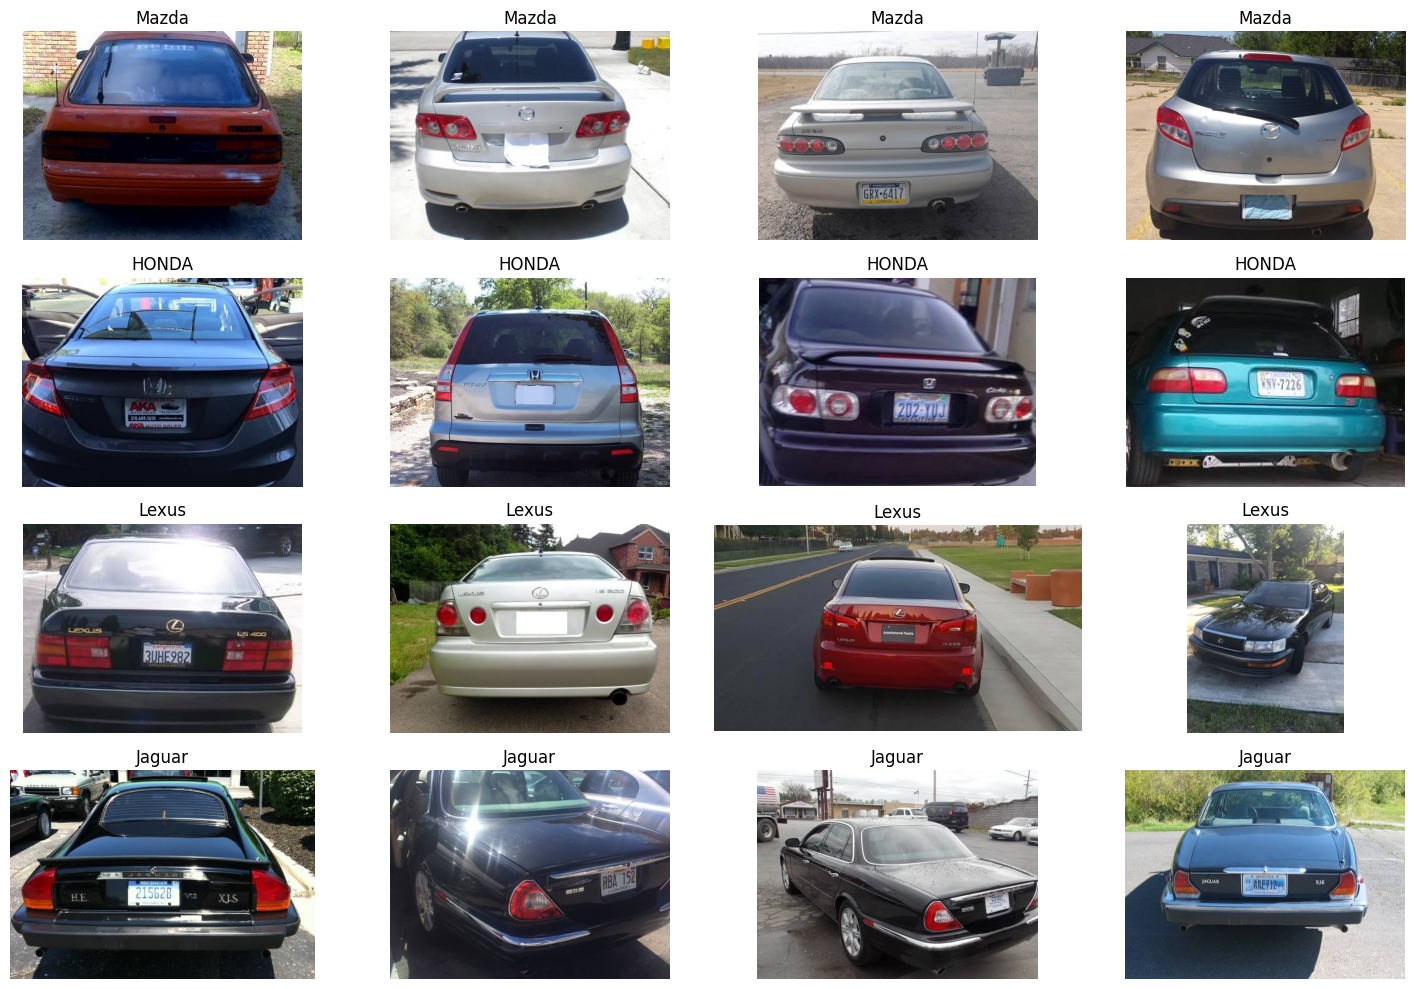

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Configuration
base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'
nb_marques_a_voir = 4  # Nombre de lignes
images_par_marque = 4  # Nombre de colonnes

# 2. Récupérer la liste des marques (dossiers)
marques = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

# Sélectionner quelques marques au hasard pour l'inspection
marques_selectionnees = random.sample(marques, nb_marques_a_voir)

# 3. Création de la figure
fig, axes = plt.subplots(nb_marques_a_voir, images_par_marque, figsize=(15, 10))

for i, marque in enumerate(marques_selectionnees):
    marque_path = os.path.join(base_path, marque)
    
    # Lister les images dans ce dossier
    toutes_images = [f for f in os.listdir(marque_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Sélectionner des images au hasard
    echantillon = random.sample(toutes_images, min(images_par_marque, len(toutes_images)))
    
    for j, img_nom in enumerate(echantillon):
        img_path = os.path.join(marque_path, img_nom)
        
        try:
            img = Image.open(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"{marque}")
            ax.axis('off') # On cache les axes pour que ce soit plus propre
        except Exception as e:
            print(f"Erreur sur {img_nom}: {e}")

plt.tight_layout()
plt.show()

# Detecter les voitures avec ResNet-50

In [9]:
from keras.applications.resnet50 import ResNet50

# define ResNet50 model
ResNet50_model = ResNet50(weights='imagenet')

#on charge des poids dèjà entraînés sur ImageNet

### Preprocessing

ResNet prend en entrée un tenseur 4D (un vecteur de cube de matrices), c'est à dire une grille d'image au format 224*224. Il faut donc les redimensionner. Le problème potentiel est que cette opération va déformer les images, ce qui peut induire le modèle en erreur. On verra pour une amélioration après les résultats des premiers test.





In [10]:
import numpy as np
from keras.preprocessing import image                  
from tqdm import tqdm

def path_to_tensor(img_path):
    """
    Transforme une image située à 'img_path' en un tenseur 4D 
    adapté aux modèles Keras (1, 224, 224, 3).
    """
    # 1. Charge l'image et la redimensionne directement en 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Convertit l'image en tableau de nombres (3D : 224, 224, 3)
    x = image.img_to_array(img)
    
    # 3. Ajoute une dimension pour en faire un "batch" de 1 image (4D : 1, 224, 224, 3)
    # C'est ce que Keras attend en entrée.
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    """
    Prend une liste de chemins d'images et les transforme en un seul gros tenseur.
    """
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)

ResNet prend en compte le format BGR, et non RGB. Il faut donc inverser les canaux. La fonction preprocess_input implémente cette fonctionnalité.

ResNet renvoie un vecteur avec les probabilités d'appartenance aux 1000 classes d'ImageNet.

In [11]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

def ResNet50_predict_labels(img_path):
    # returns prediction vector for image located at img_path
    img = preprocess_input(path_to_tensor(img_path))
    return np.argmax(ResNet50_model.predict(img))

### Fonction de détection des voitures

In [12]:
from keras.applications.resnet50 import preprocess_input

def car_detector(img_path):
    # ÉTAPE 1 : On transforme en tenseur 4D (Formatage)
    img_brut = path_to_tensor(img_path)
    
    # ÉTAPE 2 : On nettoie pour ResNet50 (Normalisation)
    img_prete = preprocess_input(img_brut)
    
    # ÉTAPE 3 : On demande au modèle de prédire
    prediction = ResNet50_model.predict(img_prete)
    indice_predit = np.argmax(prediction)
    
    # ÉTAPE 4 : On vérifie si c'est une voiture (selon nos indices)
    car_indices = [436, 468, 511, 603, 627, 656, 751, 817]
    return indice_predit in car_indices

#renvoie un booléen

### Vérification du dataset


In [13]:
from PIL import Image


base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb' 
not_car_counter = 0

for marque in os.listdir(base_path):
    marque_path = os.path.join(base_path, marque)
    
    if os.path.isdir(marque_path):
        for img_name in os.listdir(marque_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(marque_path, img_name)
                if not car_detector(img_path):
                    print("Objet autre détecté : ", img_path)
                    not_car_counter+=1
                                    

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Objet autre détecté :  C:/Users/plled/Documents/SN2/PE/VMMRdb\Audi\audi_a3_2006_00J0J_jBeDS9u8KgD_600x450.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Objet autre détecté :  C:/Users/plled/Documents/SN2/PE/VMMRdb\Audi\audi_a3_2006_00j0j_kTBo3xRp7Li_600x450.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Objet autre détecté :  C:/Users/plled/Documents/SN2/PE/VMMRdb\Audi\audi_a3_2006_00W0W_hz1WrFbcmv4_600x450.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Objet autre détecté :  C:/Users/plled/Documents/S

KeyboardInterrupt: 

# Détecter les voitures avec YOLO

In [ ]:
import os
import cv2
from ultralytics import YOLO
from tqdm import tqdm

# Configuration des chemins
base_path = r'C:/Users/plled/Documents/SN2/PE/VMMRdb'
# IDs des classes COCO pour les véhicules : 2 (car), 5 (bus), 7 (truck)
target_classes = [2, 5, 7]
conf_threshold = 0.5

# Chargement du modèle sur la RTX 4050 (device=0)
# Le modèle nano est choisi pour sa vitesse sur 82 000 fichiers
model = YOLO('yolo11n.pt')

valid_cars = 0
invalid_files = 0
total_processed = 0

# Liste de tous les chemins d'images pour la barre de progression
image_paths = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print(f"Début de l'analyse de {len(image_paths)} fichiers sur GPU...")

# Boucle de traitement avec barre de progression
for img_path in tqdm(image_paths, desc="Filtrage YOLO"):
    total_processed += 1
    
    # Inférence sur GPU
    results = model(img_path, device=0, verbose=False, conf=conf_threshold)
    
    found_vehicle = False
    for r in results:
        # On vérifie si l'une des détections appartient à nos classes cibles
        detected_classes = r.boxes.cls.tolist()
        if any(cls in target_classes for cls in detected_classes):
            found_vehicle = True
            break
            
    if found_vehicle:
        valid_cars += 1
    else:
        invalid_files += 1
        # Optionnel : log des fichiers non reconnus
        # print(f"Non-véhicule ou confiance faible : {img_path}")

# Résumé des statistiques
print("\n--- Rapport Final de Détection ---")
print(f"Total images analysées : {total_processed}")
print(f"Véhicules confirmés : {valid_cars}")
print(f"Images écartées : {invalid_files}")
print(f"Taux de validité : {(valid_cars/total_processed)*100:.2f}%")

Début de l'analyse de 82008 fichiers sur GPU...


Filtrage YOLO: 100%|██████████| 82008/82008 [14:17<00:00, 95.61it/s] 


--- Rapport Final de Détection ---
Total images analysées : 82008
Véhicules confirmés : 80587
Images écartées : 1421
Taux de validité : 98.27%


# Modèle

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# 1. Nombre de classes (à adapter selon ton nombre de dossiers de marques)
# Exemple : si tu as Audi, BMW, Citroën, etc.
num_classes = 23 

def build_car_model(num_classes):
    # Charger ResNet50 sans la couche de sortie (include_top=False)
    # On garde les poids 'imagenet' car ils sont déjà excellents pour voir les formes
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # On "gèle" le modèle de base : on ne veut pas modifier les filtres 
    # qui reconnaissent déjà les roues et les phares au début.
    base_model.trainable = False
    
    model = Sequential([
        base_model,
        
        # Réduit les données de (7, 7, 2048) à un vecteur simple de (2048)
        GlobalAveragePooling2D(),
        
        # Optionnel : une couche Dropout pour éviter que l'IA n'apprenne par cœur (overfitting)
        Dropout(0.2),
        
        # La couche finale : une unité par marque de voiture
        # 'softmax' transforme les scores en probabilités (ex: 0.92 pour Audi)
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Création du modèle
my_car_model = build_car_model(num_classes)

# Compilation
my_car_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture
my_car_model.summary()



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,634,839 (90.16 MB)

 Trainable params: 47,127 (184.09 KB)

 Non-trainable params: 23,587,712 (89.98 MB)